# Analizando viajes de taxis

En el siguiente análisis se evaluan datos de compañias de taxis junto con su número total de viajes, los barrios de destino y el número promedio de viajes terminados, así como un análisis de la diferencia de viajes en cuanto al clima en día sábado. 

# Contenido <a id='back'></a>

* [1. Análisis exploratorio de datos](#eda)
* [2. Gráficos](#graficos)
* [3. Prueba de hipótesis](#hypothesis)
* [Conclusiones](#end)

## Análisis exploratorio de datos   <a id='eda'></a>

In [2]:
#Cargar las librerias
import pandas as pd
from matplotlib import pyplot as plt
from scipy import stats as st
import numpy as np
import seaborn as sns

In [4]:
#lectura de dataset nombre de compañia y costo de viajes
df_comp_trips=pd.read_csv('moved_project_sql_result_01.csv')
#df_comp_trips=pd.read_csv('project_sql_result_01.csv')
df_comp_trips.info() #checamos si hay ausentes y tipo de datos
print()
print(df_comp_trips.head(10)) #imprime encabezados 
print()
#Corroboremos que no existen filas duplicadas
print(df_comp_trips.duplicated().sum())  # no las hay

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB

                        company_name  trips_amount
0                          Flash Cab         19558
1          Taxi Affiliation Services         11422
2                   Medallion Leasin         10367
3                         Yellow Cab          9888
4    Taxi Affiliation Service Yellow          9299
5          Chicago Carriage Cab Corp          9181
6                       City Service          8448
7                           Sun Taxi          7701
8          Star North Management LLC          7455
9  Blue Ribbon Taxi Association Inc.          5953

0


No hay valores faltantes, las columnas estan en minusculas, 

In [6]:
#lectura de datasets de ubicacion de termino de viajes y cantidad promedio de viajes que terminaron ahi en noviembre
df_loc_avtrip=pd.read_csv('moved_project_sql_result_04.csv')
#df_loc_avtrip=pd.read_csv('/datasets/project_sql_result_04.csv')
df_loc_avtrip.info() #checamos si hay ausentes y tipo de datos
print()
print(df_loc_avtrip.head(5)) # imprime encabezados
print()
#Corroboremos que no existen filas duplicadas
print(df_loc_avtrip.duplicated().sum())  # no las hay

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000

0


In [7]:
# se identifica los 10 principales barrios en términos de finalización del recorrido
top10=df_loc_avtrip.sort_values('average_trips', ascending=False).head(10)
print(top10)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


No hay valores faltantes, las columnas estan en minusculas, el tipo de columnas es correcto.

In [8]:
#lectura de datos de punto de inicio, clima y duracion del viaje
df_tripsLO=pd.read_csv('moved_project_sql_result_07.csv')
#df_tripsLO=pd.read_csv('/datasets/project_sql_result_07.csv')
df_tripsLO.info() #checamos si hay ausentes y tipo de datos
print()
print(df_tripsLO.head(5)) #imprime encabezados 
print()
#Corroboremos que si existen filas duplicadas
print(df_tripsLO.duplicated().sum())  # si pero solo el 10% y son probablemente datos correctos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB

              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0

197


Se observa que la columana de 'start_ts' es del tipo objeto y los valores que se guardan en está son del tipo fecha y por lo que se debe hacer el cambio de tipo de data.

In [11]:
# Se observan los valores para la columna de 'weather_conditions'
print(df_tripsLO['weather_conditions'].unique())
print()
#cambiar tipo de dato de start_st a datetime
df_tripsLO['start_ts']=pd.to_datetime(df_tripsLO['start_ts'])

#se corrobora el cambio de dato
print(df_tripsLO.info())

['Good' 'Bad']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 25.2+ KB
None


## Gráficos <a id='graficos'></a>

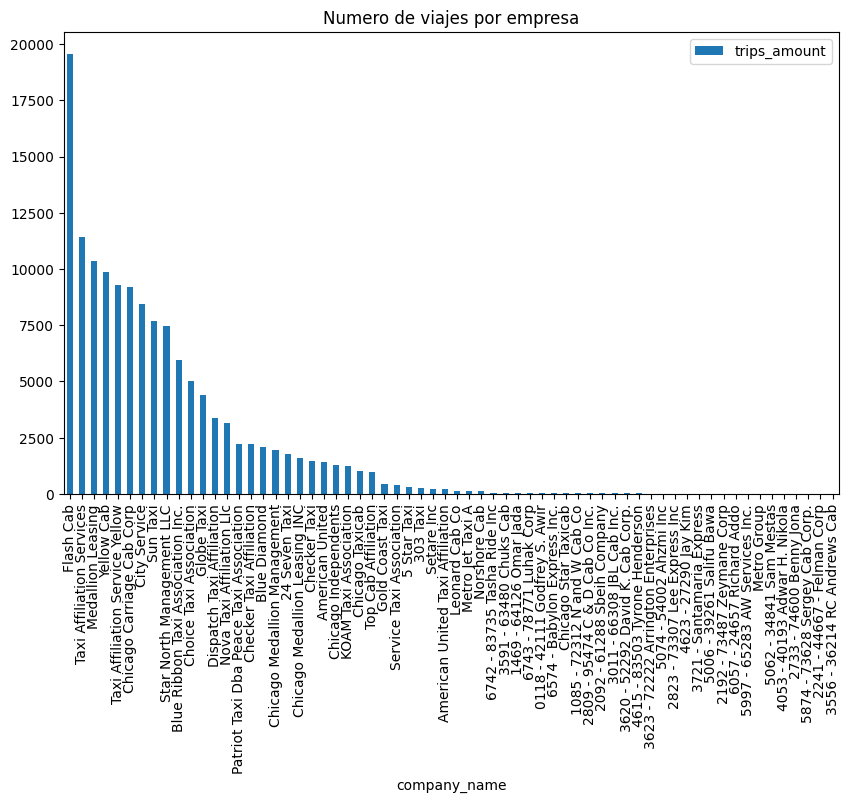

In [8]:
#empresas de taxis y número de viajes
df_comp_trips.plot(kind='bar', x='company_name',title='Numero de viajes por empresa', figsize=[10,6])
plt.show()

Se observa que la unica compañia que supera los 12500 viajes y alcanza los casi 20,000 viajes es Flash Cab, Despues de está, existen 13 compañias que acumulan en 2500 y 12500 viajes, mientras que el resto de las compañias (50 compañias de taxi) cuentan con menos de 2500 viajes promedio.

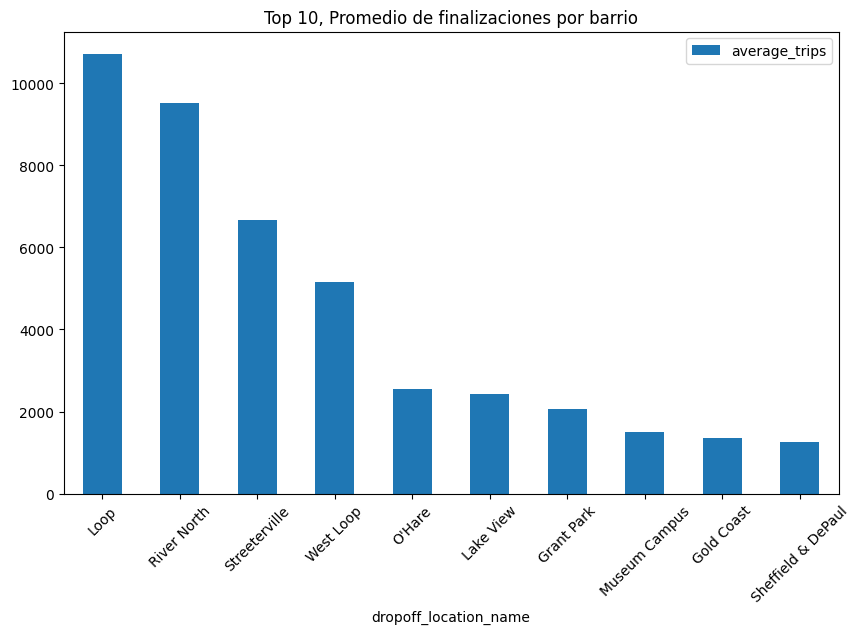

In [9]:
#los 10 barrios principales por número de finalizaciones
top10.plot(kind='bar', x='dropoff_location_name', rot=45, title='Top 10, Promedio de finalizaciones por barrio', figsize=[10,6])
plt.show()
#sns.boxplot(top10)

Del top 10 de barrios, vemos que los 3 destinos con mayor finalizacion de viajes son Loop, River North y Streeterville, con numeros de finalizacion mayores a 6000, mientras que O'Hare, Lake view, Grant Park, Museum Campus, Gold Coast y Sheffield &DePaul cuantan con menos de 3000 viajes finalizados. 

## Prueba de hipótesis <a id='hypothesis'></a>

Se plantean las siguientes hipotesis para conocer acerca de los viajes realizados:

Hipótesis nula: La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare es igual todos los sábados.

Hipótesis alternativa: La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos.


La hipótesis nula es la afirmación de ambas variable como iguales, mientras que la hipótesis alternativa las declara como diferentes. Se hace una prueba hacer una prueba de Levene para mostrar si las varianzas son iguales.  Se utiliza un nivel de significancia de 0.05; si el valor p resultante es mayor a 0.05, no podemos rechazar la hipótesis nula, y si es menor a 0.05, rechazamos la hipótesis nula, indicando que las varianzas no son iguales. Se utiliza la prueba st.ttest_ind para analizar las dos poblaciones.

In [14]:
#Weather_conditions: Good or Bad
#Dividir por poblacion de condicion de clima
bad=df_tripsLO[df_tripsLO['weather_conditions']=='Bad']
good=df_tripsLO[df_tripsLO['weather_conditions']=='Good']

#print(bad.info())
#Se filtran los datos de duracion de cada condicion climática
baddur=bad['duration_seconds']
gooddur=good['duration_seconds']

#Primero se debe conocer si las varaianzas son estadisticamente diferentes o son iguales
alpha=0.05
revar=st.levene(baddur,gooddur) # debemos mandar la lista de valores
print('El valor p:', revar.pvalue)
if(revar.pvalue < alpha):
    print('Rechazamos la hipotesis nula')
else:
    print('No podemos rechazar la hipotesis nula, las varianzas son iguales')



El valor p: 0.5332038671974493
No podemos rechazar la hipotesis nula, las varianzas son iguales


In [15]:
#dado que las varianzas son iguales, se determina equal_var=True dentro de la prueba T de Student
result=st.ttest_ind(baddur, gooddur, equal_var=True)
print('El valor p:', result.pvalue)

if(result.pvalue < alpha):
    print('Rechazamos la hipotesis nula')
else:
    print('No podemos rechazar la hipotesis nula')


El valor p: 6.517970327099473e-12
Rechazamos la hipotesis nula


Debido a que el valor de p es elevado, se rechaza la hipotesis nula y se confirma la hipotesis alternativa de que la duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos.

## Conclusiones  <a id='end'></a>

Con este análisis de dato se llegó al conocimiento que las tres principales compañias de taxi son: Flash Cab, Taxi Affiliation Service y Medallion Leasin, dentro de los barios más comunes hacia los que se hace un viaje estan Loop con mas de 10 mil finalizaciones, River North, Streeterville y Westloop, todas estas con mas de 5000 finalizaciones. Finalmente mediante una prueba estadistica se confirma que el clima influye en la duracion de viajes desde Loop hasta el aeropuerto.

Los resultados de esta análisis ayudan a proporcionar mayor presupuesto a las compañias de taxi objetivos, asi como plantear rutas de mayor afluencia o tener en cuenta las condiciones del clima para tiempos de translado y los gastos que esto conlleva.